## **Classification**

#### Dataset : https://www.kaggle.com/datasets/kabure/german-credit-data-with-risk

<BR>

The "German Credit Data with Risk" dataset contains information about individuals in Germany seeking credit. It includes various attributes such as demographic details (age, gender, marital status), financial information (income, savings, debts), and credit history (previous loans, repayment behavior).

#### **Aim** :
To implement various classification models
<br>

#### **Description** :<br>

##### ***Logistic Regression***
A statistical method used for binary classification problems. It predicts the probability that a given input belongs to a certain class by fitting data to a logistic curve.

##### ***K-Nearest Neighbors (KNN)***
A non-parametric, instance-based learning algorithm. It classifies new data points based on the majority label of the 'k' nearest points from the training dataset.

##### ***Naive Bayes***
A probabilistic classifier based on Bayes' Theorem with the assumption of independence between features. It is particularly useful for text classification and problems with a large feature space.

##### ***Decision Tree***
A flowchart-like tree structure where internal nodes represent tests on features, branches represent the outcome of the tests, and leaf nodes represent class labels. It is easy to interpret and visualize.

##### ***Random Forest***
An ensemble learning method that constructs multiple decision trees during training and outputs the mode of the classes for classification or mean prediction for regression. It reduces overfitting and improves accuracy.

##### ***Bagging***
An ensemble technique that improves the stability and accuracy of machine learning algorithms by training multiple models on random subsets of the data and aggregating their predictions. Random Forest is a popular implementation of bagging.

##### ***Boosting***
An ensemble technique that combines multiple weak learners to form a strong learner. It sequentially trains models, each correcting the errors of its predecessor. Popular boosting algorithms include AdaBoost and Gradient Boosting.

##### ***Voting***
An ensemble method where multiple models (often of different types) are trained and their predictions are combined by averaging (for regression) or by majority vote (for classification). It improves robustness and accuracy.

##### ***Support Vector Machine (SVM)***
A supervised learning model that finds the hyperplane best separating data into classes. It maximizes the margin between different classes and works well for high-dimensional spaces.

Each of these techniques has its strengths and appropriate use cases, making them valuable tools in a data scientist's toolkit.

### Loading necessary libraries

In [ ]:
# importing libraries for data handling and analysis
import pandas as pd
import numpy as np

In [ ]:
# importing libraries for data visualisations
import seaborn as sns
from matplotlib import pyplot
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib
%matplotlib inline

### Importing the data

In [ ]:
import pandas as pd

df_sourcefile = pd.read_csv(
    "/content/sample_data/german_credit_data.csv")
df_sourcefile.shape

(1000, 11)

In [ ]:
# Making a copy of the original sourcefile
df= df_sourcefile.copy()

In [ ]:
df.head()

,S.no,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [ ]:
df['Risk'].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

### Preprocessing the data

#### Checking null values

In [ ]:
#checking null values
df.isnull().sum()

S.no                  0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [ ]:
#replacing null columns with mode values as it is categorical data
df['Saving accounts'].fillna(df['Saving accounts'].mode()[0], inplace=True)
#for replacing with mean :
#df['Saving accounts'].fillna(df['Saving accounts'].mean(), inplace=True)

In [ ]:
df['Checking account'].fillna(df['Checking account'].mode()[0],inplace=True)

In [ ]:
df.isnull().sum()

S.no                0
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

#### Label encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
# Create a label encoder object
le = LabelEncoder()
# Label Encoding will be used for columns with 2 or less unique values
le_count = 0
for col in df.columns[1:]:
    if df[col].dtype == 'object':
        if len(list(df[col].unique())) <= 5:
            le.fit(df[col])
            df[col] = le.transform(df[col])
            le_count += 1
print('{} columns were label encoded.'.format(le_count))



5 columns were label encoded.


#### One hot encoding

In [ ]:
# convert rest of categorical variable into dummy
df = pd.get_dummies(df, drop_first=True)

In [ ]:
df

,S.no,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,0,67,1,2,1,0,0,1169,6,1,False,False,False,False,True,False,False
1,1,22,0,2,1,0,1,5951,48,0,False,False,False,False,True,False,False
2,2,49,1,1,1,0,0,2096,12,1,False,False,True,False,False,False,False
3,3,45,1,2,0,0,0,7882,42,1,False,False,False,True,False,False,False
4,4,53,1,2,0,0,0,4870,24,0,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,31,0,1,1,0,0,1736,12,1,False,False,False,True,False,False,False
996,996,40,1,3,1,0,0,3857,30,1,True,False,False,False,False,False,False
997,997,38,1,2,1,0,0,804,12,1,False,False,False,False,True,False,False
998,998,23,1,2,0,0,0,1845,45,0,False,False,False,False,True,False,False


 #### Correlations

<Axes: >

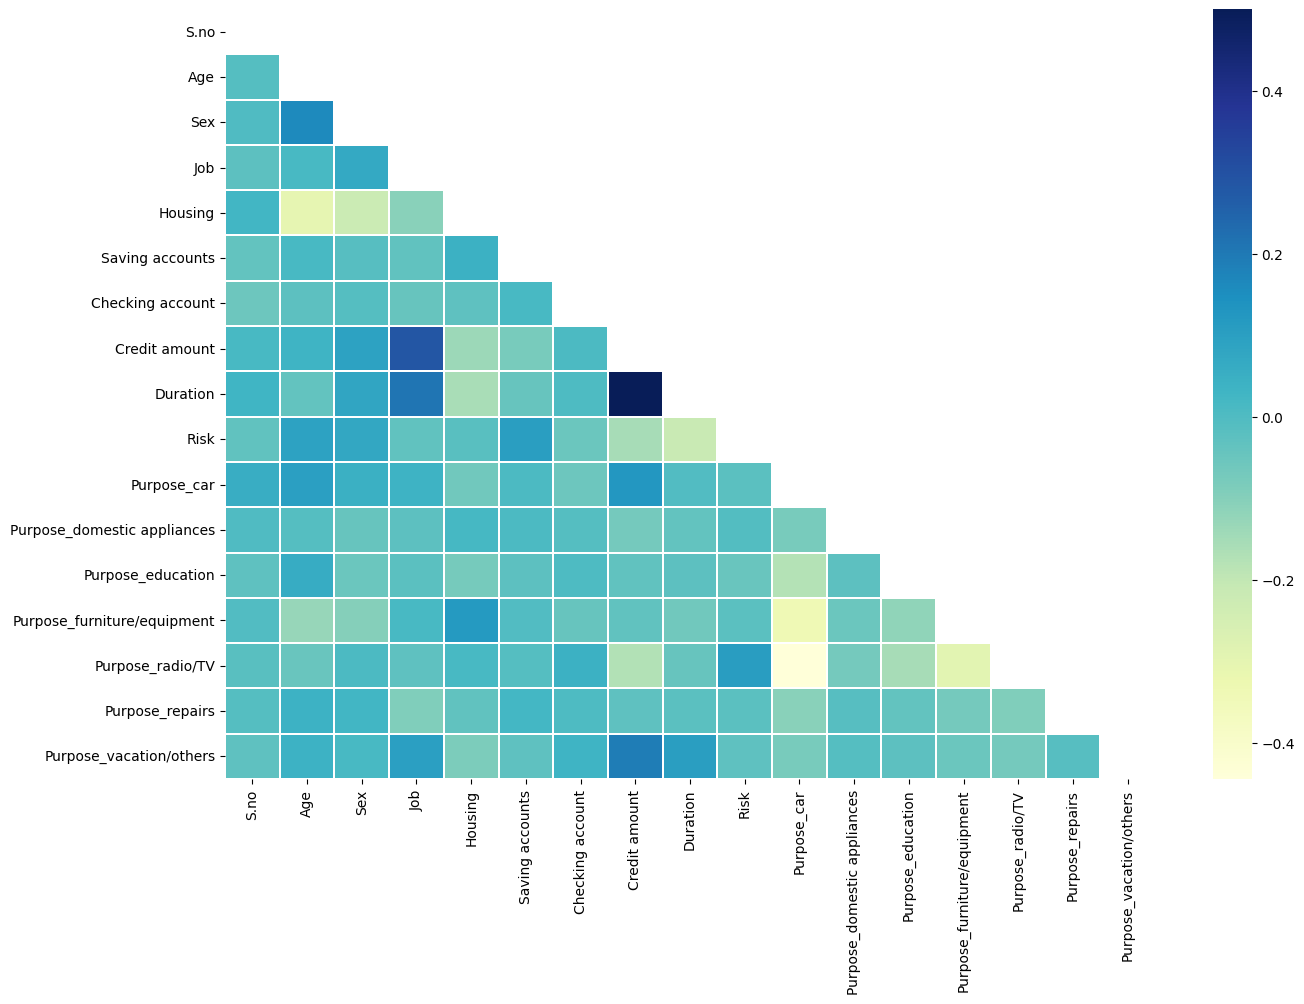

In [ ]:

# Calculate correlations
corr = df.corr()
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
# Heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr,
            vmax=.5,
            mask=mask,
            # annot=True, fmt='.2f',
            linewidths=.2, cmap="YlGnBu")

In [ ]:
# Find correlations with the target and sort
df_trans = df_sourcefile.copy()
col=["Sex","Housing","Saving accounts","Checking account","Purpose"]
df_trans[col]=df_trans[col].apply(LabelEncoder().fit_transform)
df_trans['Target'] = df_trans['Risk'].apply(
    lambda x: 0 if x == 'good' else 1)
df_trans = df_trans.drop(
    ['Risk','S.no'], axis=1)
correlations = df_trans.corr()['Target'].sort_values()
print('Most Positive Correlations: \n', correlations.tail(5))
print('\nMost Negative Correlations: \n', correlations.head(5))

Most Positive Correlations: 
 Housing          0.019315
Job              0.032735
Credit amount    0.154739
Duration         0.214927
Target           1.000000
Name: Target, dtype: float64

Most Negative Correlations: 
 Checking account   -0.350847
Saving accounts    -0.178943
Age                -0.091127
Sex                -0.075493
Purpose            -0.061145
Name: Target, dtype: float64


#### Scaling

In [ ]:
# import MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 5))
df_col = list(df.columns)
df_col.remove('Risk')
for col in df_col:
    df[col] = df[col].astype(float)
    df[[col]] = scaler.fit_transform(df[[col]])
df['Risk'] = pd.to_numeric(df['Risk'], downcast='float')
df.head()

NameError: name 'df' is not defined

In [ ]:
# assign the target to a new dataframe and convert it to a numerical feature
#df_target = df_HR[['Attrition']].copy()
target = df['Risk'].copy()

In [ ]:
# remove the target feature and redundant features from the dataset
df.drop(['Risk', 'S.no'], axis=1, inplace=True)
print('Size of Full dataset is: {}'.format(df.shape))

Size of Full dataset is: (1000, 15)


#### Splitting of dataset

In [ ]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split  # import 'train_test_split'
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score


from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier


# Common sklearn Model Helpers
from sklearn import feature_selection
from sklearn import model_selection
from sklearn import metrics
# from sklearn.datasets import make_classification

# sklearn modules for performance metrics
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve
from sklearn.metrics import auc, roc_auc_score, roc_curve, recall_score, log_loss
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, make_scorer
from sklearn.metrics import average_precision_score

In [ ]:
# Since we have class imbalance (i.e. more employees with turnover=0 than turnover=1)
# let's use stratify=y to maintain the same ratio as in the training dataset when splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(df,
                                                    target,
                                                    test_size=0.25,
                                                    random_state=7,
                                                    stratify=target)
print("Number transactions X_train dataset: ", X_train.shape)
print("Number transactions y_train dataset: ", y_train.shape)
print("Number transactions X_test dataset: ", X_test.shape)
print("Number transactions y_test dataset: ", y_test.shape)

Number transactions X_train dataset:  (750, 15)
Number transactions y_train dataset:  (750,)
Number transactions X_test dataset:  (250, 15)
Number transactions y_test dataset:  (250,)


### Classification Models

#### Logistic regression

In [ ]:
lr = LogisticRegression(solver='liblinear', random_state=7,
                                                         class_weight='balanced')
lr.fit(X_train,y_train)
Y_pred = lr.predict(X_test)

In [ ]:
# all metrics for logestic regression
accuracy_lb=metrics.accuracy_score(y_test,Y_pred)
confusion_lb=metrics.confusion_matrix(y_test,Y_pred)
precision_lb=metrics.precision_score(y_test,Y_pred)
recall_lb=metrics.recall_score(y_test,Y_pred)
f1_lb=metrics.f1_score(y_test,Y_pred)
auc_lb=metrics.roc_auc_score(y_test,Y_pred)

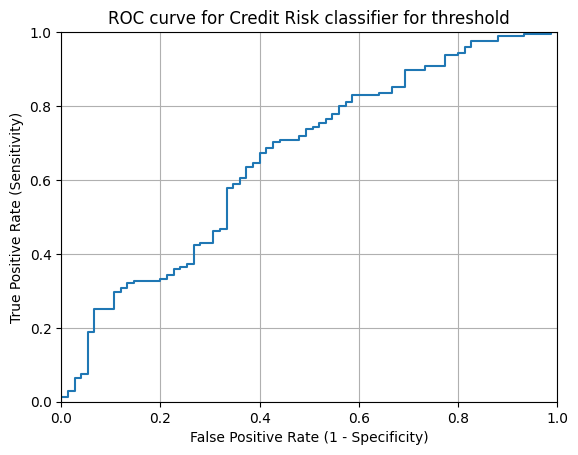

In [ ]:
from sklearn.preprocessing import binarize

y_pred_prob = lr.predict_proba(X_test)[:, 1]
y_pred_class = binarize([y_pred_prob], threshold=0.3)
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_prob)
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.title('ROC curve for Credit Risk classifier for threshold')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.grid(True)

#### KNN

In [ ]:
# KNN
kn=KNeighborsClassifier()
kn.fit(X_train,y_train)
Y_pred = kn.predict(X_test)


In [ ]:
accuracy_kb=metrics.accuracy_score(y_test,Y_pred)
confusion_kb=metrics.confusion_matrix(y_test,Y_pred)
precision_kb=metrics.precision_score(y_test,Y_pred)
recall_kb=metrics.recall_score(y_test,Y_pred)
f1_kb=metrics.f1_score(y_test,Y_pred)
auc_kb=metrics.roc_auc_score(y_test,Y_pred)

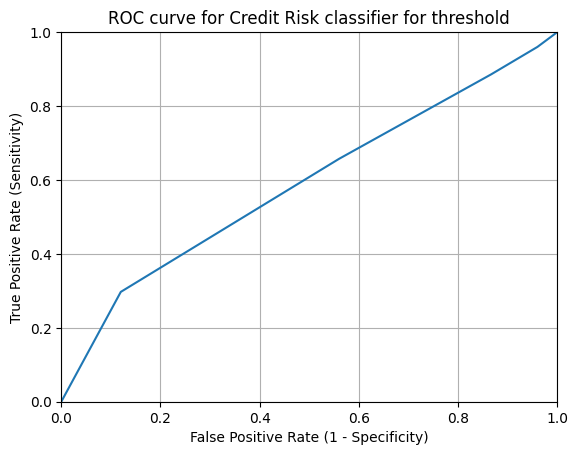

In [ ]:
from sklearn.preprocessing import binarize
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# store the predicted probabilities for class 1
y_pred_prob = kn.predict_proba(X_test)[:, 1]
y_pred_class = binarize([y_pred_prob], threshold=0.3)[0]  # Flattening the result

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Plot ROC curve
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.title('ROC curve for Credit Risk classifier for threshold')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.grid(True)
plt.show()


#### Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
nb= GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb=nb.predict(X_test)
## from sklearn.naive_bayes import BernoulliNB
#bnb= BernoulliNB()
#bnb.fit(X_train, y_train)
#y_pred_bnb=bnb.predict(X_test)

In [ ]:
# evaluation metrics of naive bayes classifier
accuracy_n=metrics.accuracy_score(y_test,y_pred_nb)
confusion_n=metrics.confusion_matrix(y_test,y_pred_nb)
precision_n=metrics.precision_score(y_test,y_pred_nb)
recall_n=metrics.recall_score(y_test,y_pred_nb)
f1_n=metrics.f1_score(y_test,y_pred_nb)
auc_n=metrics.roc_auc_score(y_test,y_pred_nb)

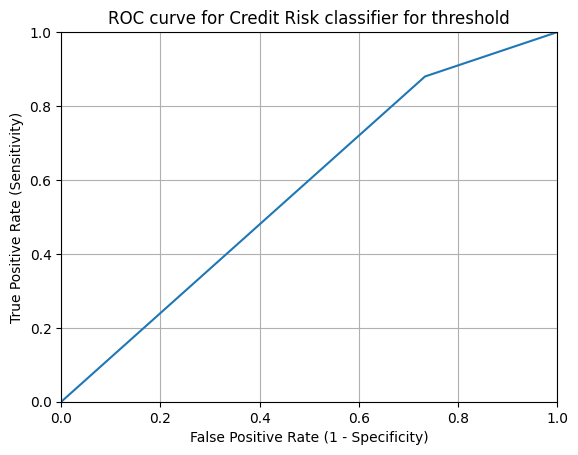

In [ ]:

y_pred_prob = nb.predict_proba(X_test)[:, 1]
y_pred_class = binarize([y_pred_prob], threshold=0.3)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_nb)

# Plot ROC curve
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.title('ROC curve for Credit Risk classifier for threshold')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.grid(True)
plt.show()

#### Decision Tree

In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn. ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, VotingClassifier

In [ ]:
dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)
y_pred_dt=dt.predict(X_test)

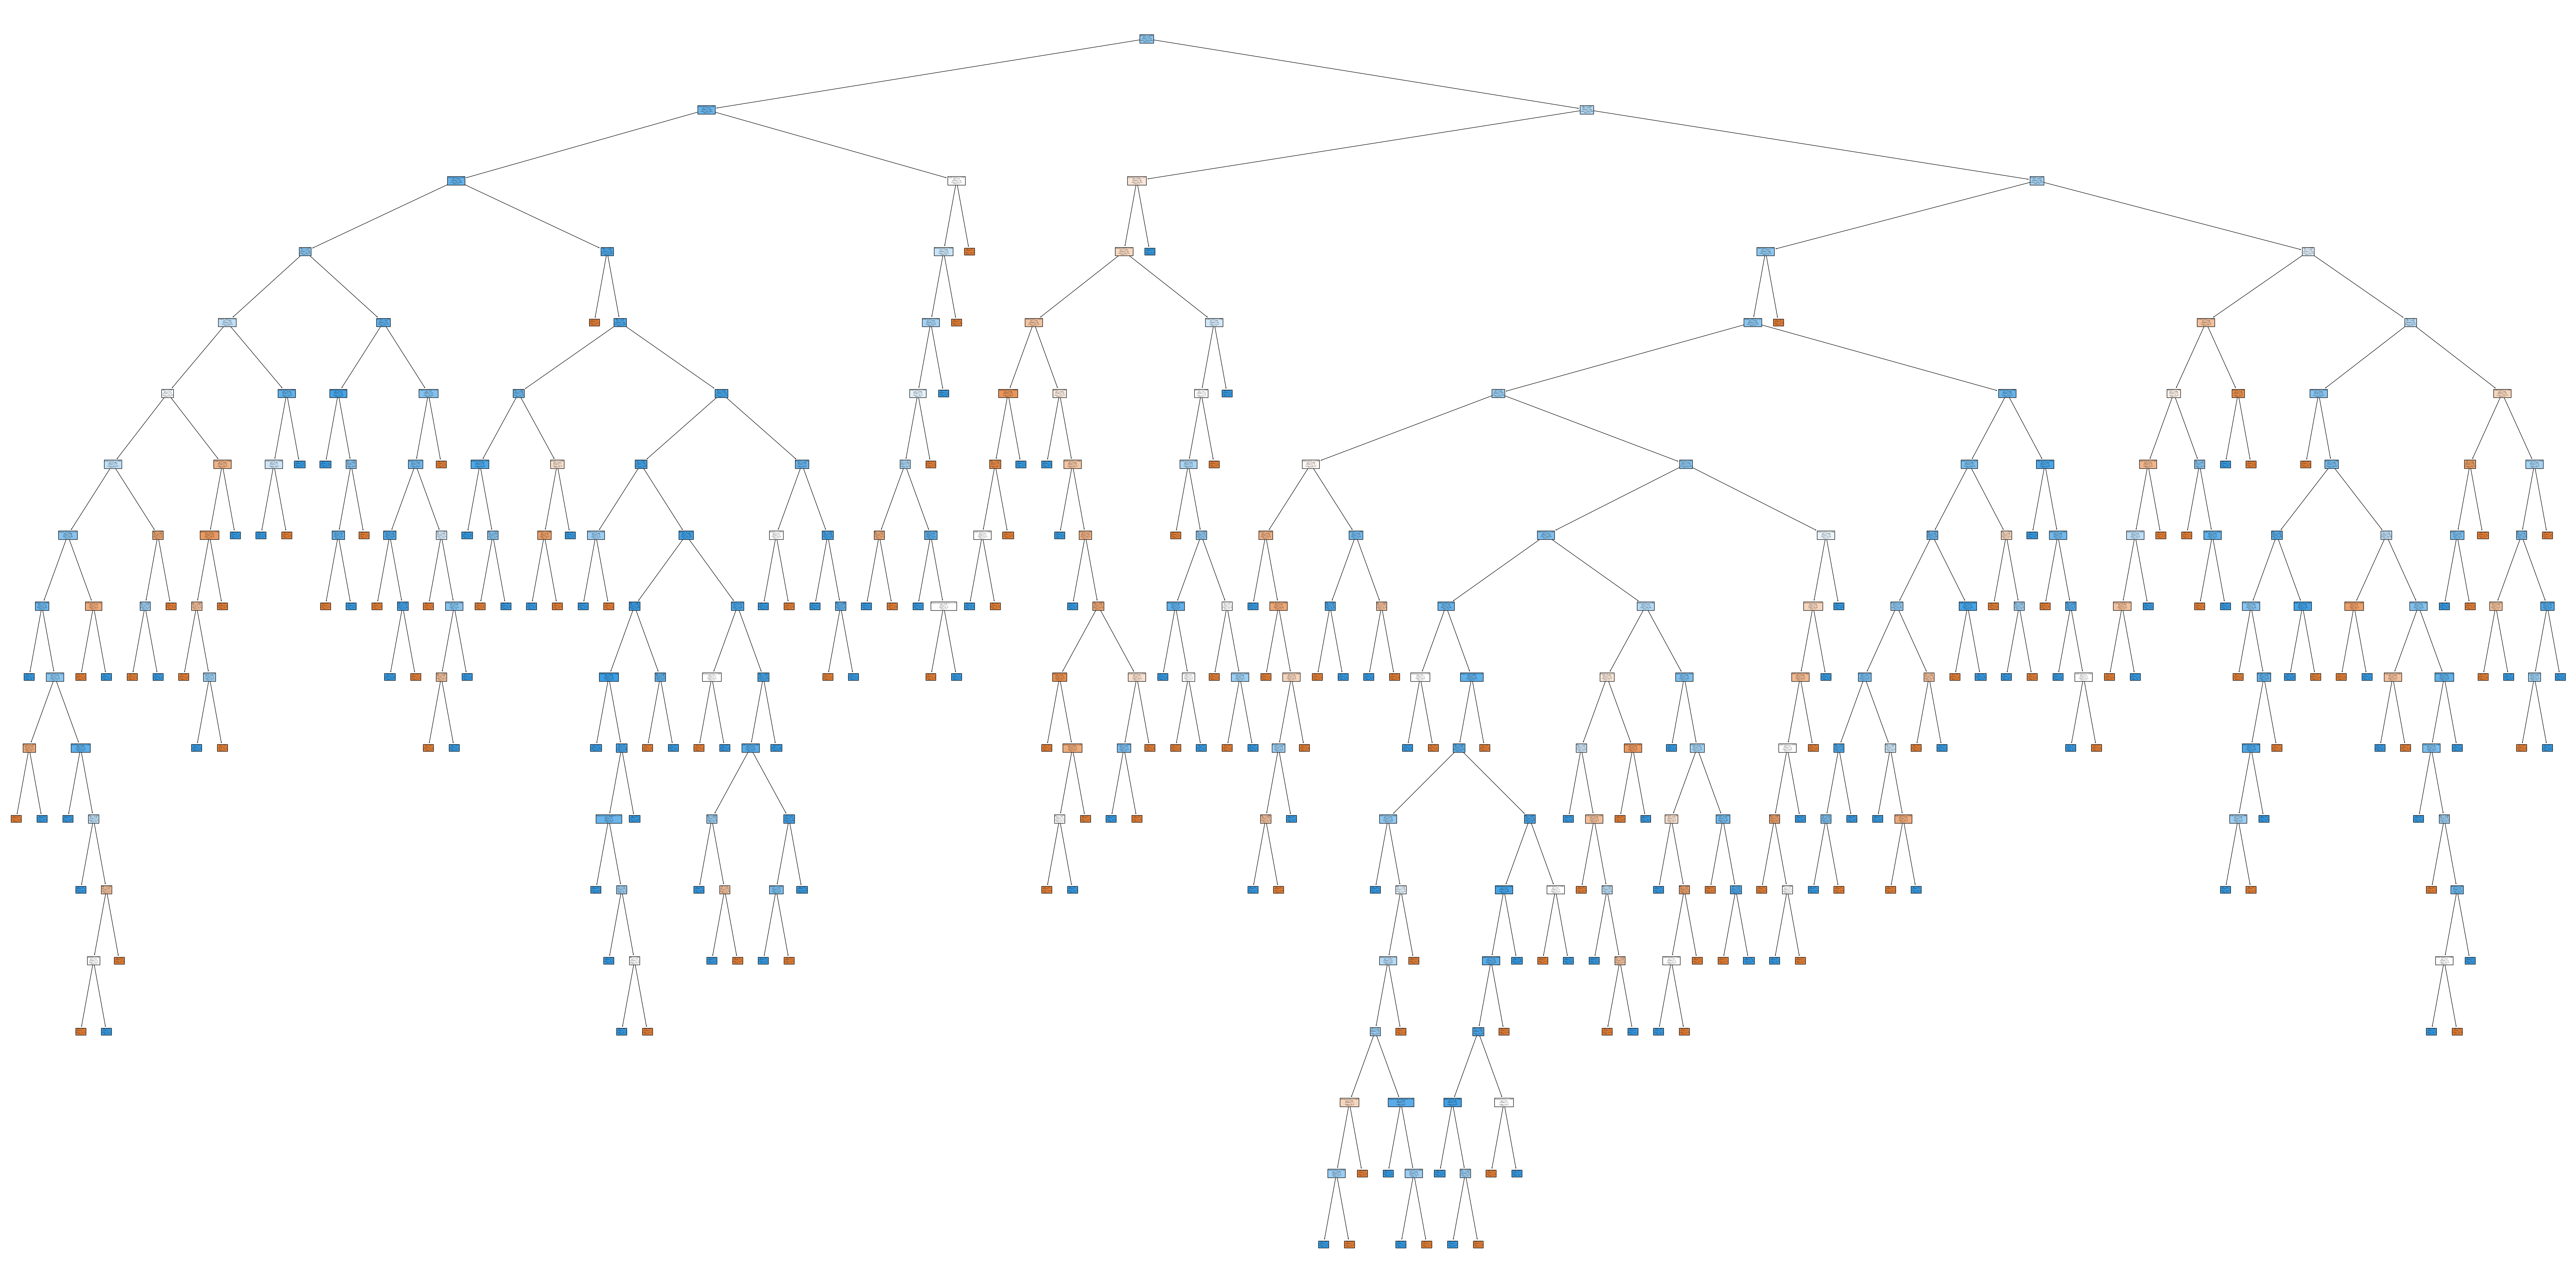

In [ ]:
from sklearn import tree
from matplotlib import pyplot as plt
fig = plt.figure(figsize=(100,50))
_ = tree.plot_tree(dt,
                   feature_names=df.columns,
                   class_names=['1','0'],
                   filled=True)

In [ ]:
# evaluation metrics of Decision tree classifier
accuracy_d=metrics.accuracy_score(y_test,y_pred_dt)
confusion_d=metrics.confusion_matrix(y_test,y_pred_dt)
precision_d=metrics.precision_score(y_test,y_pred_dt)
recall_d=metrics.recall_score(y_test,y_pred_dt)
f1_d=metrics.f1_score(y_test,y_pred_dt)
auc_d=metrics.roc_auc_score(y_test,y_pred_dt)

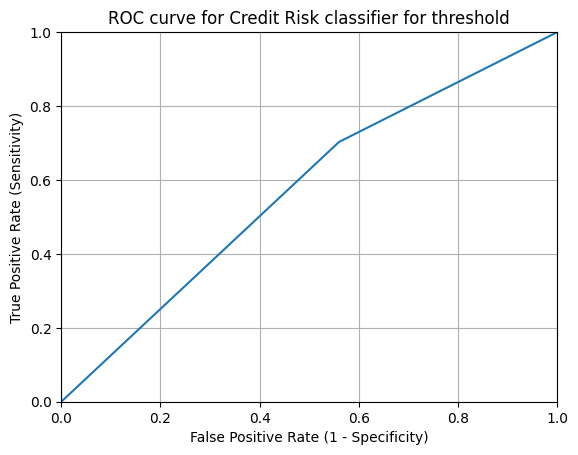

In [ ]:

y_pred_prob = dt.predict_proba(X_test)[:, 1]
y_pred_class = binarize([y_pred_prob], threshold=0.3)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test,y_pred_dt)

# Plot ROC curve
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.title('ROC curve for Credit Risk classifier for threshold')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.grid(True)
plt.show()

#### Random Forest

In [ ]:
#Random Forest - Ensemble of Descision Trees

rf = RandomForestClassifier(n_estimators=10)
rf.fit(X_train,y_train)

RandomForestClassifier(n_estimators=10)

In [ ]:
y_pred_rf=rf.predict(X_test)

In [ ]:
# evaluation metrics of random forest
accuracy_rf=metrics.accuracy_score(y_test,y_pred_rf)
confusion_rf=metrics.confusion_matrix(y_test,y_pred_rf)
precision_rf=metrics.precision_score(y_test,y_pred_rf)
recall_rf=metrics.recall_score(y_test,y_pred_rf)
f1_rf=metrics.f1_score(y_test,y_pred_rf)
auc_rf=metrics.roc_auc_score(y_test,y_pred_rf)

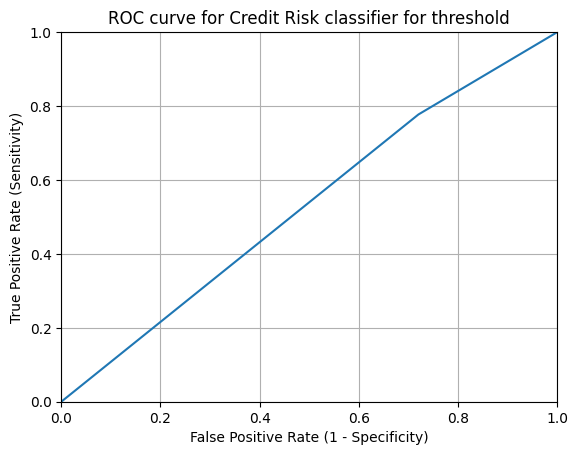

In [ ]:

y_pred_prob = rf.predict_proba(X_test)[:, 1]
y_pred_class = binarize([y_pred_prob], threshold=0.3)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test,y_pred_rf)

# Plot ROC curve
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.title('ROC curve for Credit Risk classifier for threshold')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.grid(True)
plt.show()

#### Bagging

##### 1. estimator : decision tree

In [ ]:
bg = BaggingClassifier(DecisionTreeClassifier(), max_samples= 0.2, max_features = 1.0, n_estimators = 10)
bg.fit(X_train,y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), max_samples=0.2)

In [ ]:
bg.score(X_test,y_test)
y_pred_bag=bg.predict(X_test)

In [ ]:
# evaluation metrics of bagging:dt
accuracy_bag=metrics.accuracy_score(y_test,y_pred_bag)
confusion_bag=metrics.confusion_matrix(y_test,y_pred_bag)
precision_bag=metrics.precision_score(y_test,y_pred_bag)
recall_bag=metrics.recall_score(y_test,y_pred_bag)
f1_bag=metrics.f1_score(y_test,y_pred_bag)
auc_bag=metrics.roc_auc_score(y_test,y_pred_bag)

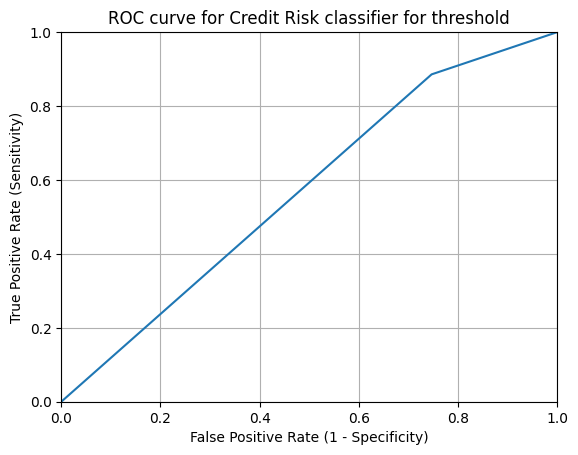

In [ ]:

y_pred_prob = bg.predict_proba(X_test)[:, 1]
y_pred_class = binarize([y_pred_prob], threshold=0.3)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test,y_pred_bag)

# Plot ROC curve
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.title('ROC curve for Credit Risk classifier for threshold')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.grid(True)
plt.show()

##### 2. estimator : knn

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
bg = BaggingClassifier(KNeighborsClassifier())
bg.fit(X_train,y_train)
bg.score(X_test,y_test)

0.656

In [ ]:
y_pred_bag2=bg.predict(X_test)

In [ ]:
# evaluation metrics of bagging:knn
accuracy_bag2=metrics.accuracy_score(y_test,y_pred_bag2)
confusion_bag2=metrics.confusion_matrix(y_test,y_pred_bag2)
precision_bag2=metrics.precision_score(y_test,y_pred_bag2)
recall_bag2=metrics.recall_score(y_test,y_pred_bag2)
f1_bag2=metrics.f1_score(y_test,y_pred_bag2)
auc_bag2=metrics.roc_auc_score(y_test,y_pred_bag2)

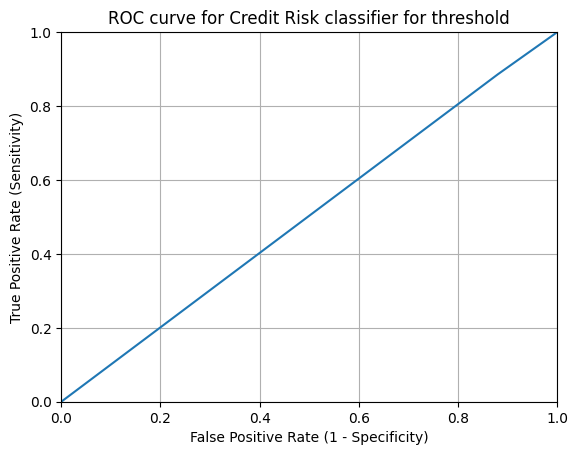

In [ ]:

y_pred_prob = bg.predict_proba(X_test)[:, 1]
y_pred_class = binarize([y_pred_prob], threshold=0.3)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test,y_pred_bag2)

# Plot ROC curve
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.title('ROC curve for Credit Risk classifier for threshold')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.grid(True)
plt.show()

##### 3.estimator :logestic regression

In [ ]:
from sklearn.linear_model import LogisticRegression
bg = BaggingClassifier(LogisticRegression(solver='liblinear'))
bg.fit(X_train,y_train)
bg.score(X_test,y_test)

0.728

In [ ]:
y_pred_bag3=bg.predict(X_test)

In [ ]:
# evaluation metrics of bagging:lr
accuracy_bag3=metrics.accuracy_score(y_test,y_pred_bag3)
confusion_bag3=metrics.confusion_matrix(y_test,y_pred_bag3)
precision_bag3=metrics.precision_score(y_test,y_pred_bag3)
recall_bag3=metrics.recall_score(y_test,y_pred_bag3)
f1_bag3=metrics.f1_score(y_test,y_pred_bag3)
auc_bag3=metrics.roc_auc_score(y_test,y_pred_bag3)

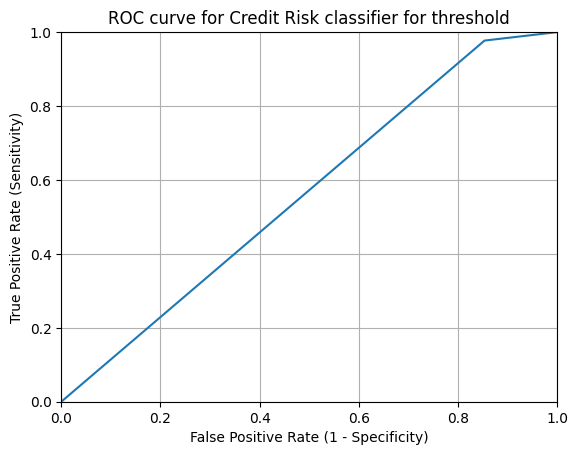

In [ ]:

y_pred_prob = bg.predict_proba(X_test)[:, 1]
y_pred_class = binarize([y_pred_prob], threshold=0.3)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test,y_pred_bag3)

# Plot ROC curve
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.title('ROC curve for Credit Risk classifier for threshold')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.grid(True)
plt.show()

### Boosting

##### 1. decision tree

In [ ]:
#Boosting - Ada Boost
adb = AdaBoostClassifier(DecisionTreeClassifier(),n_estimators = 5, learning_rate = 0.001)
adb.fit(X_train,y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(), learning_rate=0.001,
                   n_estimators=5)

In [ ]:
adb.score(X_test,y_test)
y_pred_boo=adb.predict(X_test)

In [ ]:
# evaluation metrics of boosting:dt
accuracy_boo=metrics.accuracy_score(y_test,y_pred_boo)
confusion_boo=metrics.confusion_matrix(y_test,y_pred_boo)
precision_boo=metrics.precision_score(y_test,y_pred_boo)
recall_boo=metrics.recall_score(y_test,y_pred_boo)
f1_boo=metrics.f1_score(y_test,y_pred_boo)
auc_boo=metrics.roc_auc_score(y_test,y_pred_boo)

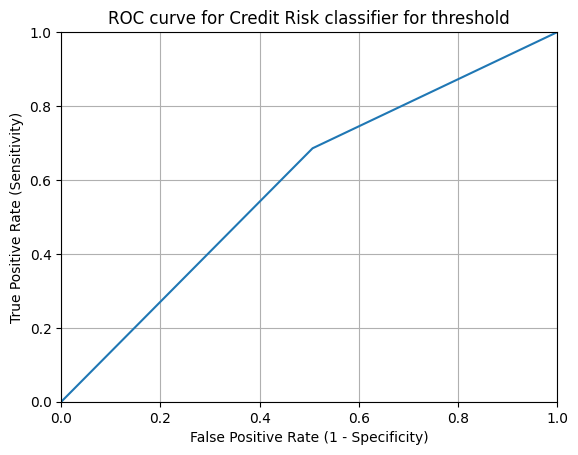

In [ ]:

y_pred_prob = adb.predict_proba(X_test)[:, 1]
y_pred_class = binarize([y_pred_prob], threshold=0.3)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test,y_pred_boo)

# Plot ROC curve
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.title('ROC curve for Credit Risk classifier for threshold')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.grid(True)
plt.show()

##### 2.logestic regression

In [ ]:
adb = AdaBoostClassifier(LogisticRegression(solver='liblinear'))
adb.fit(X_train,y_train)
adb.score(X_test,y_test)

0.74

In [ ]:
y_pred_boo2=adb.predict(X_test)

In [ ]:
# evaluation metrics of boosting:lr
accuracy_boo2=metrics.accuracy_score(y_test,y_pred_boo2)
confusion_boo2=metrics.confusion_matrix(y_test,y_pred_boo2)
precision_boo2=metrics.precision_score(y_test,y_pred_boo2)
recall_boo2=metrics.recall_score(y_test,y_pred_boo2)
f1_boo2=metrics.f1_score(y_test,y_pred_boo2)
auc_boo2=metrics.roc_auc_score(y_test,y_pred_boo2)

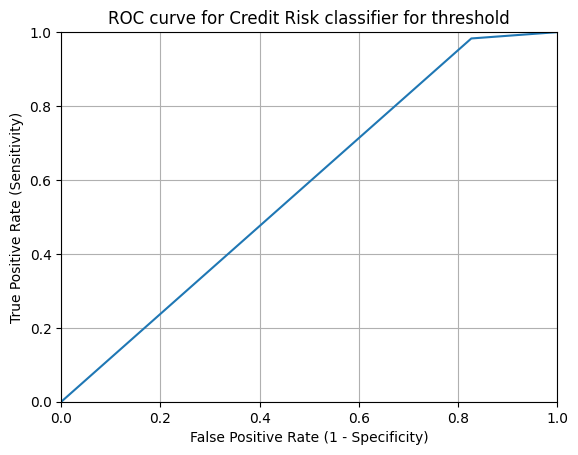

In [ ]:

y_pred_prob = adb.predict_proba(X_test)[:, 1]
y_pred_class = binarize([y_pred_prob], threshold=0.3)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test,y_pred_boo2)

# Plot ROC curve
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.title('ROC curve for Credit Risk classifier for threshold')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.grid(True)
plt.show()

#### Voting

In [ ]:
# Voting Classifier - Multiple Model Ensemble
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
lr = LogisticRegression()
dt = DecisionTreeClassifier()
svm = SVC(kernel = 'poly', degree = 2 )

In [ ]:
evc = VotingClassifier( estimators= [('lr',lr),('dt',dt),('svm',svm)], voting = 'hard')

In [ ]:
evc.fit(X_train.iloc[1:500],y_train.iloc[1:500])

VotingClassifier(estimators=[('lr', LogisticRegression()),
                             ('dt', DecisionTreeClassifier()),
                             ('svm', SVC(degree=2, kernel='poly'))])

In [ ]:
evc.score(X_test,y_test)
y_pred_evc=evc.predict(X_test)

In [ ]:
# evaluation metrics of evc
accuracy_evc=metrics.accuracy_score(y_test,y_pred_evc)
confusion_evc=metrics.confusion_matrix(y_test,y_pred_evc)
precision_evc=metrics.precision_score(y_test,y_pred_evc)
recall_evc=metrics.recall_score(y_test,y_pred_evc)
f1_evc=metrics.f1_score(y_test,y_pred_evc)
auc_evc=metrics.roc_auc_score(y_test,y_pred_evc)

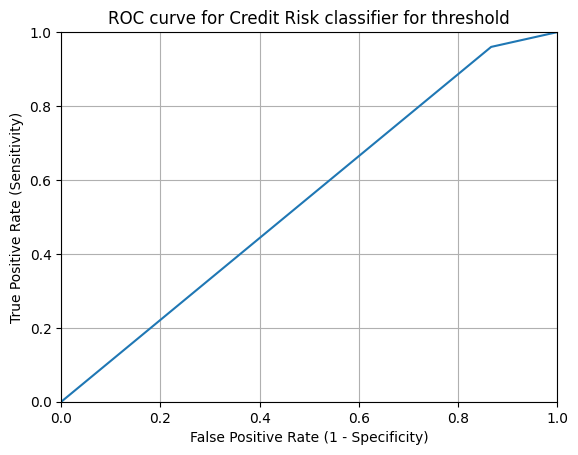

In [ ]:
y_pred_class = binarize(y_pred_prob.reshape(1, -1), threshold=0.3)[0]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test,y_pred_evc)

# Plot ROC curve
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.title('ROC curve for Credit Risk classifier for threshold')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.grid(True)
plt.show()

#### SVM

##### 1.linear kernal

In [ ]:
from sklearn import svm


In [ ]:
lf = svm.SVC(kernel='linear')

In [ ]:
lf.fit(X_train,y_train)

SVC(kernel='linear')

In [ ]:
#lf.score(X_test,Y_test)
lf.score(X_train,y_train)

0.7

In [ ]:
y_pred_lf=lf.predict(X_test)

In [ ]:
# evaluation metrics of svm:linear
accuracy_lf=metrics.accuracy_score(y_test,y_pred_lf)
confusion_lf=metrics.confusion_matrix(y_test,y_pred_lf)
precision_lf=metrics.precision_score(y_test,y_pred_lf)
recall_lf=metrics.recall_score(y_test,y_pred_lf)
f1_lf=metrics.f1_score(y_test,y_pred_lf)
auc_lf=metrics.roc_auc_score(y_test,y_pred_lf)

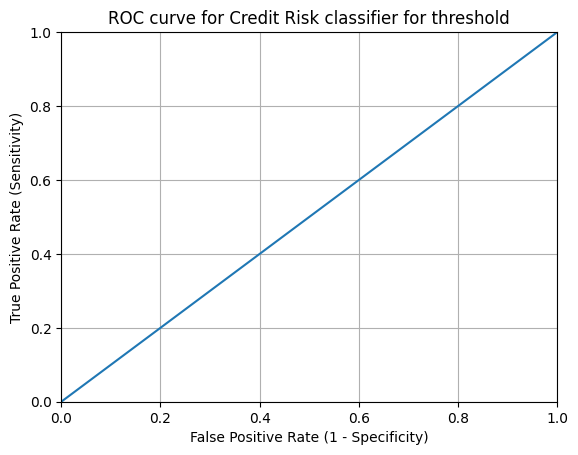

In [ ]:
y_pred_class = binarize([y_pred_lf], threshold=0.3)[0]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test,y_pred_class)

# Plot ROC curve
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.title('ROC curve for Credit Risk classifier for threshold')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.grid(True)
plt.show()

##### 2. polynomial kernal

In [ ]:
#Polynomial Kernel
svp = svm.SVC(kernel='poly', degree=2)
svp.fit(X_train,y_train)

SVC(degree=2, kernel='poly')

In [ ]:
svp.score(X_test,y_test)

0.704

In [ ]:
y_pred_svp=svp.predict(X_test)

In [ ]:
# evaluation metrics of svm:poly
accuracy_svp=metrics.accuracy_score(y_test,y_pred_svp)
confusion_svp=metrics.confusion_matrix(y_test,y_pred_svp)
precision_svp=metrics.precision_score(y_test,y_pred_svp)
recall_svp=metrics.recall_score(y_test,y_pred_svp)
f1_svp=metrics.f1_score(y_test,y_pred_svp)
auc_svp=metrics.roc_auc_score(y_test,y_pred_svp)

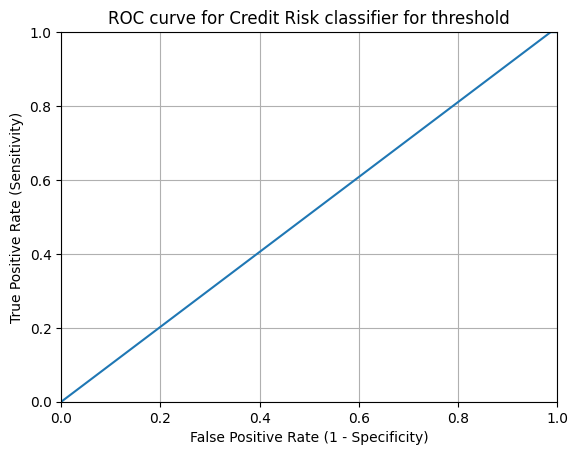

In [ ]:
y_pred_class = binarize([y_pred_svp], threshold=0.3)[0]  # Flattening the result

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test,y_pred_svp)

# Plot ROC curve
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.title('ROC curve for Credit Risk classifier for threshold')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.grid(True)
plt.show()

##### 3. Gaussian rbf kernal

In [ ]:
#Gaussian RBF Kernel

svgu = svm.SVC(kernel='rbf')
svgu.fit(X_train,y_train)
svgu.score(X_test,y_test)

0.7

In [ ]:
y_pred_svgu=svgu.predict(X_test)

In [ ]:
# evaluation metrics of svm:rbf
accuracy_svgu=metrics.accuracy_score(y_test,y_pred_svgu)
confusion_svgu=metrics.confusion_matrix(y_test,y_pred_svgu)
precision_svgu=metrics.precision_score(y_test,y_pred_svgu)
recall_svgu=metrics.recall_score(y_test,y_pred_svgu)
f1_svgu=metrics.f1_score(y_test,y_pred_svgu)
auc_svgu=metrics.roc_auc_score(y_test,y_pred_svgu)

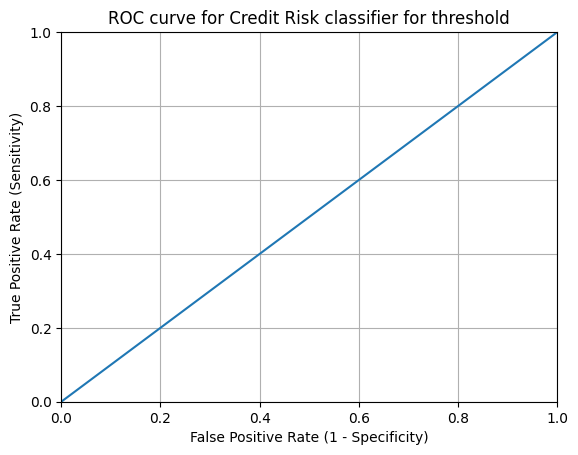

In [ ]:
y_pred_class = binarize([y_pred_svgu], threshold=0.3)[0]  # Flattening the result

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test,y_pred_svgu)

# Plot ROC curve
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.title('ROC curve for Credit Risk classifier for threshold')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.grid(True)
plt.show()

##### 4. sigmoid kernal

In [ ]:
#Sigmoid Kernel

svs = svm.SVC(kernel='sigmoid')
svs.fit(X_train,y_train)
svs.score(X_test,y_test)

0.628

In [ ]:
y_pred_svs=svgu.predict(X_test)

In [ ]:
# evaluation metrics of svm:sigmoid
accuracy_svs=metrics.accuracy_score(y_test,y_pred_svs)
confusion_svs=metrics.confusion_matrix(y_test,y_pred_svs)
precision_svs=metrics.precision_score(y_test,y_pred_svs)
recall_svs=metrics.recall_score(y_test,y_pred_svs)
f1_svs=metrics.f1_score(y_test,y_pred_svs)
auc_svs=metrics.roc_auc_score(y_test,y_pred_svs)

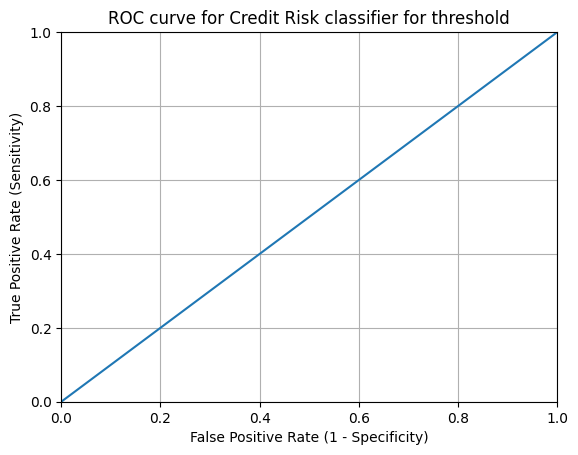

In [ ]:
y_pred_class = binarize([y_pred_svs], threshold=0.3)[0]  # Flattening the result

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test,y_pred_svs)

# Plot ROC curve
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.title('ROC curve for Credit Risk classifier for threshold')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.grid(True)
plt.show()

#### deep learning

In [ ]:
!pip install tensorflow

In [ ]:
df.shape

(1000, 15)

In [ ]:
X=df
y=target
from numpy import loadtxt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import pandas as pd
model = Sequential()
model.add(Dense(12, input_shape=(15,), activation='relu'))
model.add(Dense(10, activation='relu'))

model.add(Dense(1, activation='sigmoid'))
# compile the keras model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# fit the keras model on the dataset
model.fit(X, y, epochs=30,validation_split=0.10,batch_size=10)
# evaluate the keras mod

_, accuracy = model.evaluate(X, y)
print('Accuracy: %.2f' % (accuracy*100))

Epoch 1/30
90/90 [==============================] - 1s 4ms/step - loss: 0.9326 - accuracy: 0.3011 - val_loss: 0.7675 - val_accuracy: 0.3100
Epoch 2/30
90/90 [==============================] - 0s 3ms/step - loss: 0.7329 - accuracy: 0.4100 - val_loss: 0.7005 - val_accuracy: 0.5100
Epoch 3/30
90/90 [==============================] - 0s 3ms/step - loss: 0.6858 - accuracy: 0.5833 - val_loss: 0.6791 - val_accuracy: 0.6300
Epoch 4/30
90/90 [==============================] - 0s 2ms/step - loss: 0.6567 - accuracy: 0.6744 - val_loss: 0.6504 - val_accuracy: 0.6900
Epoch 5/30
90/90 [==============================] - 0s 2ms/step - loss: 0.6347 - accuracy: 0.6978 - val_loss: 0.6376 - val_accuracy: 0.6700
Epoch 6/30
90/90 [==============================] - 0s 3ms/step - loss: 0.6228 - accuracy: 0.6989 - val_loss: 0.6299 - val_accuracy: 0.6800
Epoch 7/30
90/90 [==============================] - 0s 2ms/step - loss: 0.6111 - accuracy: 0.6989 - val_loss: 0.6236 - val_accuracy: 0.6800
Epoch 8/30
90/90 [==

In [ ]:
y_pred_dl=model.predict(X_test)
y_pred_dl= [1 if pred > 0.5 else 0 for pred in y_pred_dl]

8/8 [==============================] - 0s 2ms/step


In [ ]:
accuracy_dl=metrics.accuracy_score(y_test,y_pred_dl)
confusion_dl=metrics.confusion_matrix(y_test,y_pred_dl)
precision_dl=metrics.precision_score(y_test,y_pred_dl)
recall_dl=metrics.recall_score(y_test,y_pred_dl)
f1_dl=metrics.f1_score(y_test,y_pred_dl)
auc_dl=metrics.roc_auc_score(y_test,y_pred_dl)

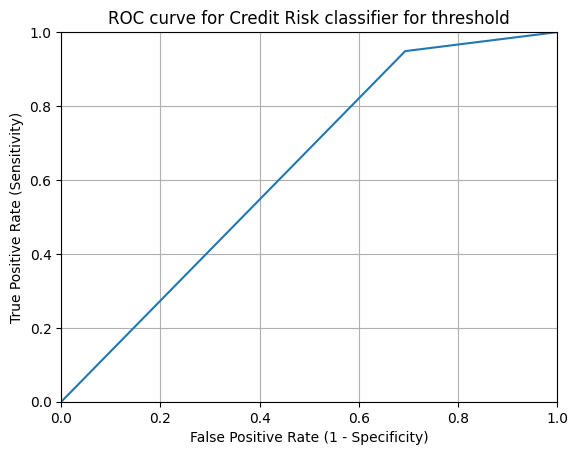

In [ ]:
y_pred_class = binarize([y_pred_dl], threshold=0.3)[0]  # Flattening the result

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test,y_pred_dl)

# Plot ROC curve
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.title('ROC curve for Credit Risk classifier for threshold')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.grid(True)
plt.show()

#### Conclusion

**Conclusion:**
<br>
for the german credit dataset taken different classification models are applied.
<br>
For this dataset the  ***deep learning*** model gives the highest accuracy of 0.747.
<br> The second best model for this dataset is the ***boosting with linear regression***  model with an accuracy of 0.740 .
<br>

For this dataset ***boosting with decision tree*** gives the least accuracy of 0.616 .
